<a href="https://colab.research.google.com/github/Ab-tldr/Movie-review-Sentiment-Analysis/blob/main/multivariate_lstm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATA_PATH = "/content/drive/MyDrive/air_quality/"

In [ ]:
df = pd.read_csv(DATA_PATH + "dataset/city_day.csv", low_memory=False)


In [ ]:
stations = pd.read_csv(DATA_PATH +'dataset/stations.csv')

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values(['City', 'Date'], inplace=True)

###AQI CALCULATION

In [ ]:
def get_subindex(pollutant, value):
    if pd.isna(value) or value <= 0: return 0
    bp = {
        'PM2.5': [(0,30,0,50), (30,60,50,100), (60,90,100,200), (90,120,200,300), (120,250,300,400), (250,1000,400,500)],
        'PM10': [(0,50,0,50), (50,100,50,100), (100,250,100,200), (250,350,200,300), (350,430,300,400), (430,1000,400,500)],
        'NO2': [(0,40,0,50), (40,80,50,100), (80,180,100,200), (180,280,200,300), (280,400,300,400), (400,1000,400,500)],
        'SO2': [(0,40,0,50), (40,80,50,100), (80,380,100,200), (380,800,200,300), (800,1600,300,400), (1600,2000,400,500)],
        'CO': [(0,1,0,50), (1,2,50,100), (2,10,100,200), (10,17,200,300), (17,34,300,400), (34,100,400,500)],
        'NH3': [(0,200,0,50), (200,400,50,100), (400,800,100,200), (800,1200,200,300), (1200,1800,300,400), (1800,3000,400,500)]
    }
    if pollutant not in bp: return 0
    for (cl, ch, il, ih) in bp[pollutant]:
        if cl <= value <= ch:
            return il + (value - cl) * (ih - il) / (ch - cl)
    return 500



In [ ]:
pollutants = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'NH3']


In [ ]:
for p in pollutants:
    df[f'{p}_si'] = df[p].apply(lambda x: get_subindex(p, x))

df['New_AQI'] = df[[f'{p}_si' for p in pollutants]].max(axis=1)

In [ ]:
city_data = df[df['City'] == 'Delhi'].copy()
city_data['Date'] = pd.to_datetime(city_data['Date'])
city_data = city_data.sort_values('Date').set_index('Date')


In [ ]:
features = ['New_AQI','PM2.5','PM10','NO2','SO2','CO','NH3']

multi_series = city_data[features].resample('D').mean()


In [ ]:
print("Missing values before cleaning:")
print(multi_series.isnull().sum())

Missing values before cleaning:
New_AQI      0
PM2.5        2
PM10        77
NO2          2
SO2        110
CO           0
NH3          9
dtype: int64


In [ ]:
multi_series = multi_series.interpolate(method='time')


In [ ]:
multi_series = multi_series.fillna(method='bfill')


/tmp/ipykernel_191/1459039213.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  multi_series = multi_series.fillna(method='bfill')


In [ ]:
multi_series['AQI_lag1'] = multi_series['New_AQI'].shift(1)
multi_series['AQI_lag2'] = multi_series['New_AQI'].shift(2)
multi_series['AQI_roll3'] = multi_series['New_AQI'].rolling(3).mean()
multi_series['AQI_roll7'] = multi_series['New_AQI'].rolling(7).mean()



In [ ]:
multi_series = multi_series.dropna()


In [ ]:
print("\nMissing values after cleaning:")
print(multi_series.isnull().sum())


Missing values after cleaning:
New_AQI      0
PM2.5        0
PM10         0
NO2          0
SO2          0
CO           0
NH3          0
AQI_lag1     0
AQI_lag2     0
AQI_roll3    0
AQI_roll7    0
dtype: int64


In [ ]:
multi_series.describe()

,New_AQI,PM2.5,PM10,NO2,SO2,CO,NH3,AQI_lag1,AQI_lag2,AQI_roll3,AQI_roll7
count,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000
mean,233.226514,116.830925,230.792949,50.852959,15.675560,1.940815,41.742449,233.345689,233.430945,233.334383,233.498464
std,107.460631,82.877503,120.905270,22.715933,7.961605,2.501123,16.698051,107.469882,107.486400,105.718022,102.233901
min,14.745833,10.240000,18.590000,10.630000,2.340000,0.000000,6.780000,14.745833,14.745833,30.838333,36.321429
25%,137.535556,56.870000,136.430000,33.900000,10.140000,0.910000,31.090000,137.580000,137.580000,140.483704,143.615556
50%,229.643333,94.290000,213.490000,47.260000,14.340000,1.240000,37.970000,229.649206,230.591624,227.608889,226.583440
75%,329.443320,152.910000,309.090000,63.620000,19.550000,1.860000,48.630000,329.602564,329.615385,327.897573,324.682864
max,449.460047,685.360000,796.880000,162.500000,71.560000,30.440000,166.700000,449.460047,449.460047,442.123750,436.038095


<Axes: >

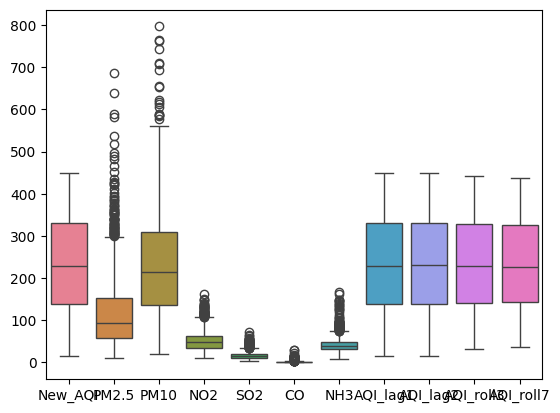

In [ ]:
sns.boxplot(data=multi_series)

In [ ]:
multi_series_log = np.log1p(multi_series)


In [ ]:
scaler = RobustScaler()
scaled_data = scaler.fit_transform(multi_series_log)


In [ ]:
scaler2 = MinMaxScaler()
scaled_data2 = scaler2.fit_transform(multi_series_log)


In [ ]:
def create_windows(data, lookback=30):

    X, y = [], []

    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, :])
        y.append(data[i, 0])

    return np.array(X), np.array(y)

In [ ]:
LOOKBACK = 30
X, y = create_windows(scaled_data, LOOKBACK)


In [ ]:
X2, y2 = create_windows(scaled_data2, LOOKBACK)


In [ ]:
print("Input shape:", X.shape)


Input shape: (1971, 30, 11)


In [ ]:
X2.shape

(1971, 30, 11)

Train Test Split

In [ ]:
split1 = int(0.7 * len(X))
split2 = int(0.9 * len(X))

X_train, X_val, X_test = X[:split1], X[split1:split2], X[split2:]
y_train, y_val, y_test = y[:split1], y[split1:split2], y[split2:]

X_train2, X_val2, X_test2 = X2[:split1], X2[split1:split2], X2[split2:]
y_train2, y_val2, y_test2 = y2[:split1], y2[split1:split2], y2[split2:]

In [ ]:
n_features = X.shape[2]


In [ ]:
from tensorflow.keras.regularizers import l2


In [ ]:
model = Sequential([
    LSTM(64, return_sequences=True,
         input_shape=(LOOKBACK, n_features),
         kernel_regularizer=l2(0.001)),
    Dropout(0.4),

    LSTM(32, kernel_regularizer=l2(0.001)),
    Dropout(0.3),

    Dense(1)
])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model2 = Sequential([
    LSTM(64, return_sequences=True,
         input_shape=(LOOKBACK, n_features),
         kernel_regularizer=l2(0.001)),
    Dropout(0.4),

    LSTM(32, kernel_regularizer=l2(0.001)),
    Dropout(0.3),

    Dense(1)
])



In [ ]:
model.compile(optimizer='adam', loss='mae')
model.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_38 (LSTM)                  │ (None, 30, 64)         │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_39 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,905 (124.63 KB)

 Trainable params: 31,905 (124.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model2.compile(optimizer='adam', loss='mae')
model2.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_40 (LSTM)                  │ (None, 30, 64)         │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_41 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,905 (124.63 KB)

 Trainable params: 31,905 (124.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)


In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.1162 - val_loss: 0.0942
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.1150 - val_loss: 0.0922
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.1143 - val_loss: 0.0922
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - loss: 0.1137 - val_loss: 0.0911
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 0.1118 - val_loss: 0.0954
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.1151 - val_loss: 0.0970
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.1139 - val_loss: 0.1028


In [ ]:
history2 = model2.fit(
    X_train2, y_train2,
    epochs=100,
    batch_size=32,
    validation_data=(X_val2, y_val2),
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0361 - val_loss: 0.0283
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0360 - val_loss: 0.0287
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0369 - val_loss: 0.0282
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 0.0354 - val_loss: 0.0289
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0358 - val_loss: 0.0285
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0361 - val_loss: 0.0286
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0367 - val_loss: 0.0290
Epoch 8/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0351 - val_loss: 0.0320
Epoch 9/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0355 - val_loss: 0.0283
Epoch 10/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0354 - val_loss: 0.0279
Epoch 11/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0351 - val_loss: 0.0287
Epoch 12/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step

In [ ]:
preds = model.predict(X_test)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [ ]:
preds2 = model2.predict(X_test2)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [ ]:
dummy_preds = np.zeros((len(preds), scaled_data.shape[1]))
dummy_actual = np.zeros((len(y_test), scaled_data.shape[1]))

In [ ]:
dummy_preds[:,0] = preds.flatten()
dummy_actual[:,0] = y_test.flatten()

In [ ]:
inv_scaled_preds = scaler.inverse_transform(dummy_preds)[:,0]
inv_scaled_actual = scaler.inverse_transform(dummy_actual)[:,0]


In [ ]:
inv_preds = np.expm1(inv_scaled_preds)
inv_actual = np.expm1(inv_scaled_actual)


In [ ]:
dummy_preds2 = np.zeros((len(preds2), scaled_data2.shape[1]))
dummy_actual2 = np.zeros((len(y_test2), scaled_data2.shape[1]))

dummy_preds2[:,0] = preds2.flatten()
dummy_actual2[:,0] = y_test2.flatten()

inv_preds2 = scaler2.inverse_transform(dummy_preds2)[:,0]
inv_preds2 = np.expm1(inv_preds2)
inv_actual2 = scaler2.inverse_transform(dummy_actual2)[:,0]
inv_actual2 = np.expm1(inv_actual2)


In [ ]:
rmse = np.sqrt(mean_squared_error(inv_actual, inv_preds))
mae  = mean_absolute_error(inv_actual, inv_preds)

print(f"\nFinal RMSE: {rmse:.2f}")
print(f"Final MAE : {mae:.2f}")


Final RMSE: 18.86
Final MAE : 14.34


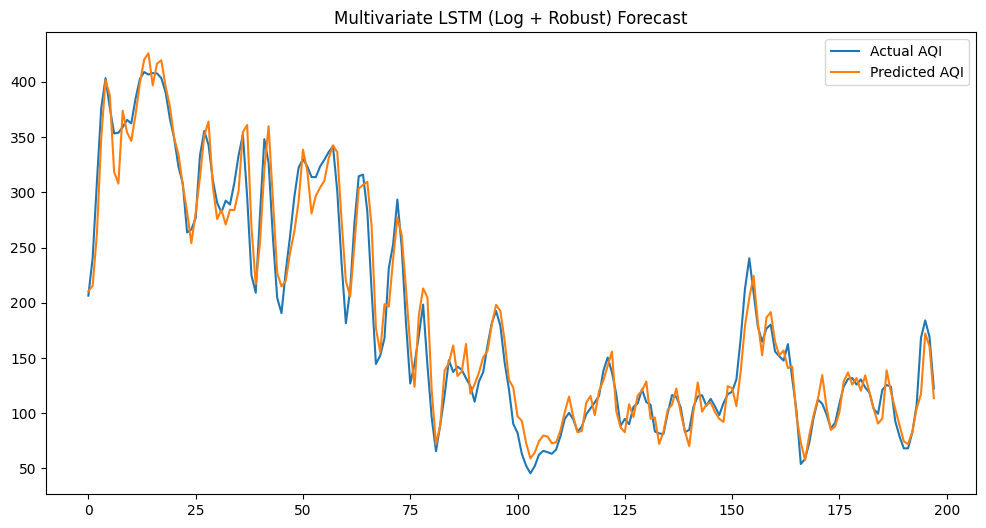

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(inv_actual, label='Actual AQI')
plt.plot(inv_preds, label='Predicted AQI')
plt.title("Multivariate LSTM (Log + Robust) Forecast")
plt.legend()
plt.show()


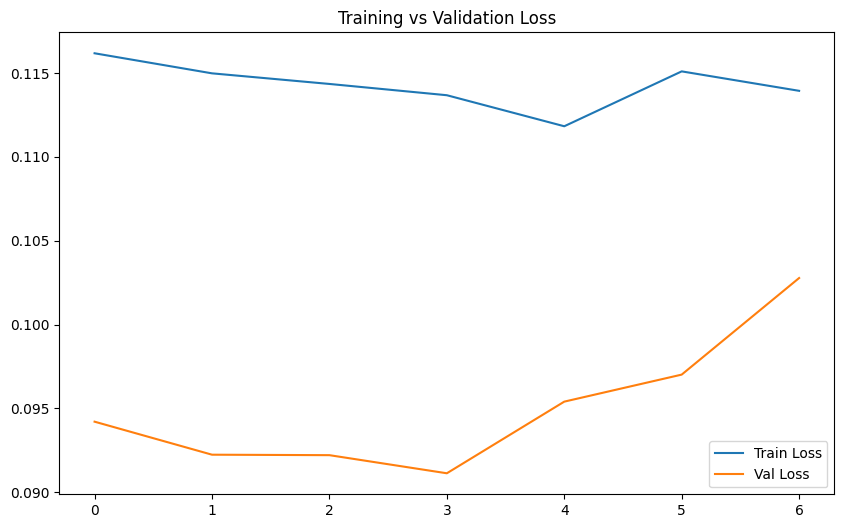

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


MinMAx

In [ ]:
rmse2 = np.sqrt(mean_squared_error(inv_actual2, inv_preds2))
mae2  = mean_absolute_error(inv_actual2, inv_preds2)

print(f"\nFinal RMSE: {rmse2:.2f}")
print(f"Final MAE : {mae2:.2f}")




Final RMSE: 19.99
Final MAE : 15.24


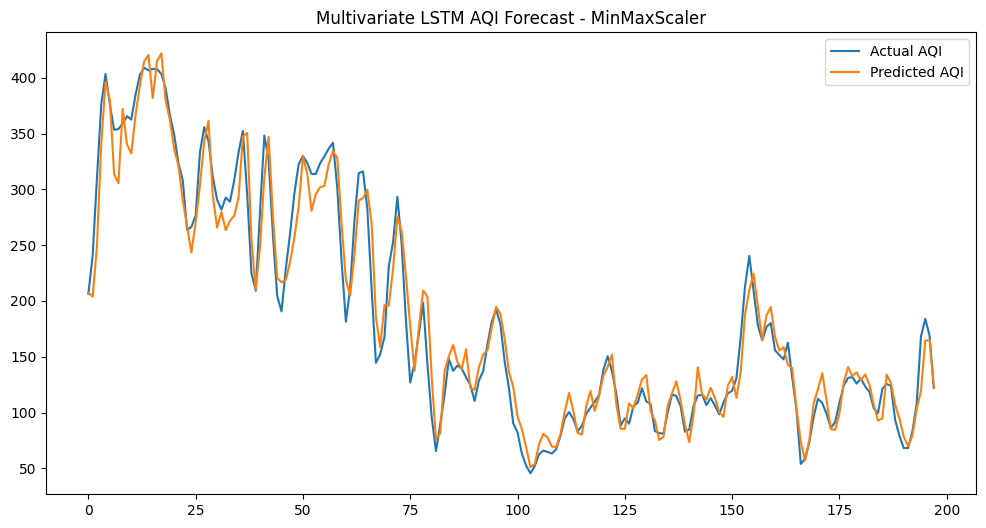

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(inv_actual2, label='Actual AQI')
plt.plot(inv_preds2, label='Predicted AQI')
plt.title("Multivariate LSTM AQI Forecast - MinMaxScaler")
plt.legend()
plt.show()



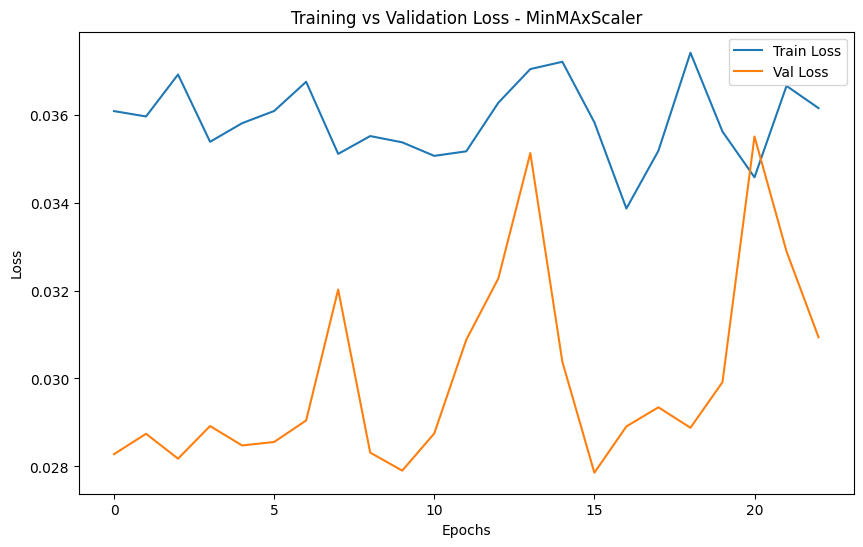

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Val Loss')
plt.title("Training vs Validation Loss - MinMAxScaler")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()